Selecciona 'Dataset_Bioinformatic_Depured.csv':


Saving Dataset_Bioinformatic_Depured.csv to Dataset_Bioinformatic_Depured.csv


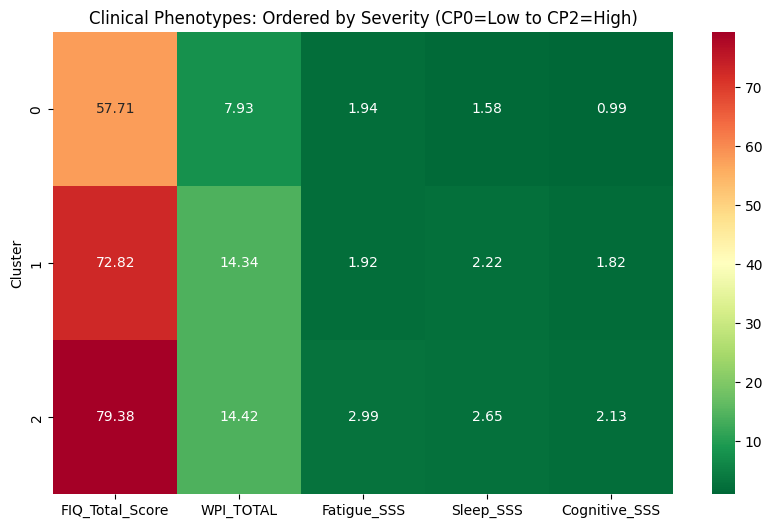

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ==========================================
# BLOQUE 1: LOCALIZACION DE COHORTES
# ==========================================

import pandas as pd
import numpy as np
import io
import joblib
from google.colab import files
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CARGA Y PREPROCESADO (Cohorte A - Baseline)
# ==========================================
print("Selecciona 'Dataset_Bioinformatic_Depured.csv':")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]), sep=';', encoding='latin1', decimal=',')
df.columns = df.columns.str.strip()

# Filtro: Sesión Basal y Grupo A
col_sesion = df.columns[5]
df_basal = df[df[col_sesion].astype(str).str.contains('Primera', na=False)].copy()
df_discovery = df_basal[df_basal['Cohort_Group'] == 'Group A'].copy()

# Mapeo de columnas por posición
col_fiq_total = df.columns[47]
cols_sss_num = df.columns[51:54].tolist()
col_age = 'Edad' if 'Edad' in df.columns else df.columns[7]
col_gender = 'Sexo' if 'Sexo' in df.columns else df.columns[8]

df_discovery = df_discovery.rename(columns={
    col_fiq_total: 'FIQ_Total_Score',
    cols_sss_num[0]: 'Fatigue_SSS',
    cols_sss_num[1]: 'Sleep_SSS',
    cols_sss_num[2]: 'Cognitive_SSS'
})

features = ['FIQ_Total_Score', 'WPI_TOTAL', 'Fatigue_SSS', 'Sleep_SSS', 'Cognitive_SSS']
X_raw = df_discovery[features].dropna()
df_final = df_discovery.loc[X_raw.index].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# ==========================================
# 2. VALIDACIÓN (DATOS PARA GRÁFICA COMBINADA)
# ==========================================
wcss, sil_scores = [], []
range_k = range(2, 7)
for k in range_k:
    km = KMeans(n_clusters=k, init='k-means++', n_init=100, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

pd.DataFrame({'k': range_k, 'WCSS': wcss, 'Silhouette': sil_scores}).to_csv('Data_Validation_Plots.csv', index=False, sep=';')

# ==========================================
# 3. CLUSTERING Y REORDENAMIENTO POR SEVERIDAD
# ==========================================
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=100, random_state=42)
initial_clusters = kmeans.fit_predict(X_scaled)

# Lógica de reordenamiento: CP1 (Leve) -> CP2 (Medio) -> CP3 (Severo)
# Basado en el promedio de FIQ_Total_Score
temp_df = pd.DataFrame({'Cluster_Orig': initial_clusters, 'FIQ': X_raw['FIQ_Total_Score']})
order = temp_df.groupby('Cluster_Orig')['FIQ'].mean().sort_values().index
mapping = {old: new for new, old in enumerate(order)}
df_final['Cluster'] = [mapping[c] for c in initial_clusters]

# Actualizar centros reordenados para el modelo exportado
sorted_centers = kmeans.cluster_centers_[order]
kmeans.cluster_centers_ = sorted_centers

# Guardar "Cerebro" del modelo
joblib.dump(kmeans, 'kmeans_model_A_ordered.pkl')
joblib.dump(scaler, 'scaler_A.pkl')

# ==========================================
# 4. DATOS PARA MAPA DE CALOR Y TABLA 1
# ==========================================
# Guardar matriz del Heatmap (Datos para publicación)
heatmap_data = df_final.groupby('Cluster')[features].mean()
heatmap_data.to_csv('Data_Heatmap_Profiles.csv', sep=';')

# Generar Visualización
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, cmap='RdYlGn_r', fmt=".2f")
plt.title('Clinical Phenotypes: Ordered by Severity (CP0=Low to CP2=High)')
plt.savefig('Heatmap_Final.png', dpi=300)
plt.show()

# Función Tabla 1
def generate_table(df, cont_vars, cat_vars):
    rows = []
    for var in cont_vars:
        grps = [df[df['Cluster'] == i][var].dropna() for i in range(3)]
        means = [f"{g.mean():.2f} ± {g.std():.2f}" for g in grps]
        _, p = stats.f_oneway(*grps)
        rows.append([var] + means + [f"{p:.4e}"])

    for var in cat_vars:
        counts = []
        for i in range(3):
            n_c = len(df[df['Cluster'] == i])
            n_f = len(df[(df['Cluster'] == i) & (df[var].astype(str).str.contains('Fem|Muj', case=False))])
            counts.append(f"{n_f} ({(n_f/n_c)*100:.1f}%)")
        ct = pd.crosstab(df[var], df['Cluster'])
        _, p, _, _ = stats.chi2_contingency(ct)
        rows.append([var + " (n, %)"] + counts + [f"{p:.4e}"])
    return pd.DataFrame(rows, columns=['Variable', 'CP1 (Low)', 'CP2 (Moderate)', 'CP3 (High)', 'p-value'])

table_1 = generate_table(df_final, [col_age] + features, [col_gender])
table_1.to_csv('Table_1_Statistical_Analysis.csv', index=False, sep=';')

# ==========================================
# 5. DESCARGAS FINALES
# ==========================================
for f in ['Data_Validation_Plots.csv', 'Data_Heatmap_Profiles.csv', 'Table_1_Statistical_Analysis.csv',
          'Heatmap_Final.png', 'kmeans_model_A_ordered.pkl']:
    files.download(f)


--- Procesando Validación para: Group B ---


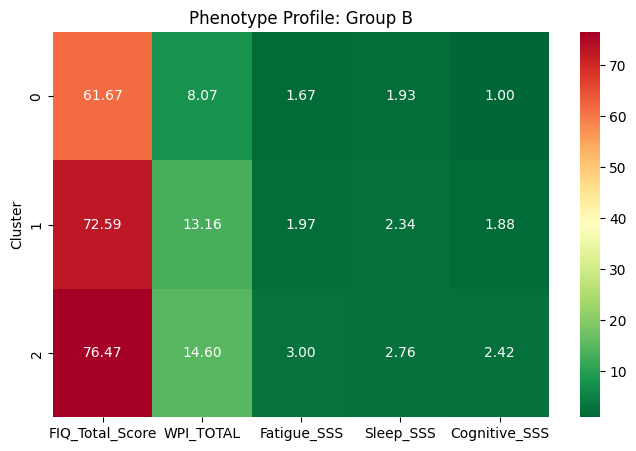

Distribución en Group B:
Cluster
0    15
1    32
2    50
Name: count, dtype: int64

--- Procesando Validación para: Group C ---


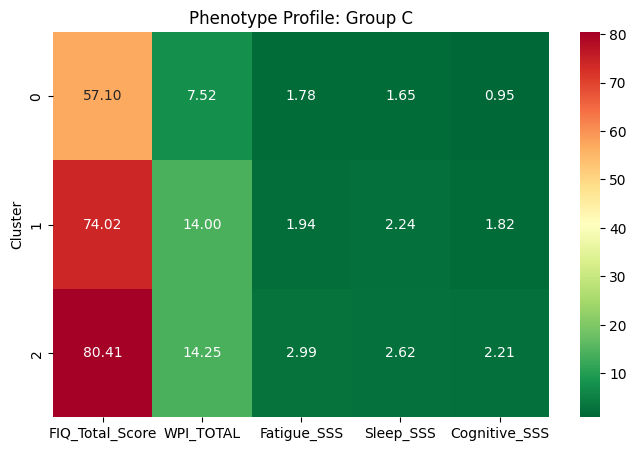

Distribución en Group C:
Cluster
0    167
1    224
2    270
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Validación externa completada. Archivos de las Cohortes B y C descargados.


In [2]:
 # ==========================================
# BLOQUE 2: VALIDACIÓN EXTERNA (COHORTES B Y C)
# ==========================================

def validar_cohorte(nombre_grupo):
    print(f"\n--- Procesando Validación para: {nombre_grupo} ---")

    # 1. Filtrar datos de la cohorte específica
    df_val = df_basal[df_basal['Cohort_Group'] == nombre_grupo].copy()

    # 2. Renombrar variables para consistencia (mismo mapeo que en A)
    df_val = df_val.rename(columns={
        col_fiq_total: 'FIQ_Total_Score',
        cols_sss_num[0]: 'Fatigue_SSS',
        cols_sss_num[1]: 'Sleep_SSS',
        cols_sss_num[2]: 'Cognitive_SSS'
    })

    # 3. Limpieza de nulos en los features de interés
    X_val_raw = df_val[features].dropna()
    df_val_final = df_val.loc[X_val_raw.index].copy()

    # 4. TRANSFORMACIÓN (Usando el scaler de la Cohorte A)
    # Importante: Solo transform(), NO fit_transform()
    X_val_scaled = scaler.transform(X_val_raw)

    # 5. PREDICCIÓN (Usando el modelo de la Cohorte A)
    # Importante: predict(), NO fit_predict()
    df_val_final['Cluster'] = kmeans.predict(X_val_scaled)

    # 6. Generar Datos para Mapa de Calor
    val_heatmap_data = df_val_final.groupby('Cluster')[features].mean()
    val_heatmap_data.to_csv(f'Data_Heatmap_{nombre_grupo}.csv', sep=';')

    # Visualización rápida del Heatmap
    plt.figure(figsize=(8, 5))
    sns.heatmap(val_heatmap_data, annot=True, cmap='RdYlGn_r', fmt=".2f")
    plt.title(f'Phenotype Profile: {nombre_grupo}')
    plt.show()

    # 7. Generar Tabla Estadística (Tabla de Validación)
    tab_val = generate_table(df_val_final, [col_age] + features, [col_gender])
    tab_val.to_csv(f'Table_Validation_{nombre_grupo}.csv', index=False, sep=';')

    print(f"Distribución en {nombre_grupo}:")
    print(df_val_final['Cluster'].value_counts().sort_index())

    return df_val_final, tab_val

# Ejecutar validación para Grupo B
df_B_final, tabla_B = validar_cohorte('Group B')

# Ejecutar validación para Grupo C
df_C_final, tabla_C = validar_cohorte('Group C')

# ==========================================
# 8. DESCARGAS DE VALIDACIÓN
# ==========================================
for f in ['Data_Heatmap_Group B.csv', 'Table_Validation_Group B.csv',
          'Data_Heatmap_Group C.csv', 'Table_Validation_Group C.csv']:
    files.download(f)

print("\n Validación externa completada. Archivos de las Cohortes B y C descargados.")

In [3]:

import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr

def verificar_estabilidad_clinica(df_A_final, df_B_final, df_C_final, features):
    print("=== INFORME DE VERIFICACIÓN DE VALIDACIÓN EXTERNA ===\n")

    # 1. Obtener perfiles (centros) de cada cohorte
    centroides_A = df_A_final.groupby('Cluster')[features].mean()
    centroides_B = df_B_final.groupby('Cluster')[features].mean()
    centroides_C = df_C_final.groupby('Cluster')[features].mean()

    for i in range(3): # Para cada CP (0, 1, 2)
        print(f"--- Análisis de Estabilidad para CP{i+1} ---")

        # Correlación A vs B
        corr_AB, _ = pearsonr(centroides_A.iloc[i], centroides_B.iloc[i])
        mse_AB = mean_squared_error(centroides_A.iloc[i], centroides_B.iloc[i])

        # Correlación A vs C
        corr_AC, _ = pearsonr(centroides_A.iloc[i], centroides_C.iloc[i])
        mse_AC = mean_squared_error(centroides_A.iloc[i], centroides_C.iloc[i])

        print(f"  > Cohorte B: Correlación r = {corr_AB:.4f} | MSE = {mse_AB:.4f}")
        print(f"  > Cohorte C: Correlación r = {corr_AC:.4f} | MSE = {mse_AC:.4f}")

        if corr_AB > 0.95 and corr_AC > 0.95:
            print(f"  RESULTADO: CP{i+1} es ALTAMENTE ESTABLE entre cohortes.")
        else:
            print(f"  NOTA: CP{i+1} muestra variaciones menores entre cohortes.")
        print("-" * 45)

    # 2. Resumen de consistencia global
    # Guardar reporte para el manuscrito
    reporte_validacion = pd.concat([centroides_A, centroides_B, centroides_C],
                                  keys=['Cohorte A', 'Cohorte B', 'Cohorte C'])
    reporte_validacion.to_csv('Validacion_Externa_Consistencia.csv', sep=';')
    print("\n Reporte de consistencia guardado como 'Validacion_Externa_Consistencia.csv'")

# Ejecutar la verificación
verificar_estabilidad_clinica(df_final, df_B_final, df_C_final, features)

=== INFORME DE VERIFICACIÓN DE VALIDACIÓN EXTERNA ===

--- Análisis de Estabilidad para CP1 ---
  > Cohorte B: Correlación r = 0.9999 | MSE = 3.1849
  > Cohorte C: Correlación r = 1.0000 | MSE = 0.1142
  RESULTADO: CP1 es ALTAMENTE ESTABLE entre cohortes.
---------------------------------------------
--- Análisis de Estabilidad para CP2 ---
  > Cohorte B: Correlación r = 0.9998 | MSE = 0.2931
  > Cohorte C: Correlación r = 1.0000 | MSE = 0.3103
  RESULTADO: CP2 es ALTAMENTE ESTABLE entre cohortes.
---------------------------------------------
--- Análisis de Estabilidad para CP3 ---
  > Cohorte B: Correlación r = 1.0000 | MSE = 1.7092
  > Cohorte C: Correlación r = 1.0000 | MSE = 0.2233
  RESULTADO: CP3 es ALTAMENTE ESTABLE entre cohortes.
---------------------------------------------

 Reporte de consistencia guardado como 'Validacion_Externa_Consistencia.csv'


In [4]:
# ==========================================
# BLOQUE 3: CONSOLIDACIÓN FINAL (TABLA COMPARATIVA A-B-C)
# ==========================================

def preparar_resumen(df, cohorte_name):
    # Calcular medias y SD por clúster
    resumen = df.groupby('Cluster')[features].agg(['mean', 'std'])

    # Formatear como "Media ± SD"
    for col in features:
        resumen[col, 'formatted'] = resumen[col].apply(
            lambda x: f"{x['mean']:.2f} ± {x['std']:.2f}", axis=1
        )

    # Quedarnos solo con las columnas formateadas
    resumen_final = resumen.xs('formatted', axis=1, level=1)
    resumen_final.insert(0, 'Cohorte', cohorte_name)
    resumen_final.insert(1, 'N', df.groupby('Cluster').size())
    return resumen_final

# 1. Generar resúmenes individuales
res_A = preparar_resumen(df_final, 'Discovery (A)')
res_B = preparar_resumen(df_B_final, 'Validation (B)')
res_C = preparar_resumen(df_C_final, 'Validation (C)')

# 2. Concatenar y organizar para la publicación
tabla_maestra = pd.concat([res_A, res_B, res_C]).sort_index()
tabla_maestra.index.name = 'Phenotype'
tabla_maestra.reset_index(inplace=True)

# Re-etiquetar Clústeres para el paper
mapeo_nombres = {0: 'CP1 (Low Impact)', 1: 'CP2 (Moderate)', 2: 'CP3 (High Impact)'}
tabla_maestra['Phenotype'] = tabla_maestra['Phenotype'].map(mapeo_nombres)

# 3. Guardar y Mostrar
tabla_maestra.to_csv('Final_Consolidated_Phenotypes_ABC.csv', sep=';', index=False)
display(tabla_maestra)

# 4. Descarga automática
files.download('Final_Consolidated_Phenotypes_ABC.csv')

print("\n Tabla maestra consolidada generada. Este es el corazón de tus resultados.")

,Phenotype,Cohorte,N,FIQ_Total_Score,WPI_TOTAL,Fatigue_SSS,Sleep_SSS,Cognitive_SSS
0,CP1 (Low Impact),Discovery (A),69,57.71 ± 11.72,7.93 ± 3.98,1.94 ± 0.54,1.58 ± 0.74,0.99 ± 0.74
1,CP1 (Low Impact),Validation (B),15,61.67 ± 9.08,8.07 ± 5.23,1.67 ± 0.62,1.93 ± 0.59,1.00 ± 0.76
2,CP1 (Low Impact),Validation (C),167,57.10 ± 12.67,7.52 ± 4.29,1.78 ± 0.76,1.65 ± 0.91,0.95 ± 0.75
3,CP2 (Moderate),Discovery (A),104,72.82 ± 8.33,14.34 ± 3.36,1.92 ± 0.27,2.22 ± 0.71,1.82 ± 0.66
4,CP2 (Moderate),Validation (C),224,74.02 ± 8.11,14.00 ± 3.49,1.94 ± 0.31,2.24 ± 0.64,1.82 ± 0.70
5,CP2 (Moderate),Validation (B),32,72.59 ± 7.78,13.16 ± 3.98,1.97 ± 0.18,2.34 ± 0.70,1.88 ± 0.71
6,CP3 (High Impact),Discovery (A),95,79.38 ± 8.69,14.42 ± 3.97,2.99 ± 0.10,2.65 ± 0.60,2.13 ± 0.78
7,CP3 (High Impact),Validation (B),50,76.47 ± 10.34,14.60 ± 4.32,3.00 ± 0.00,2.76 ± 0.43,2.42 ± 0.64
8,CP3 (High Impact),Validation (C),270,80.41 ± 8.87,14.25 ± 4.02,2.99 ± 0.12,2.62 ± 0.56,2.21 ± 0.75


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


 Tabla maestra consolidada generada. Este es el corazón de tus resultados.


In [5]:
# ==========================================
# FASE 3: ANÁLISIS DE TRAYECTORIAS (VERSIÓN POR ÍNDICES)
# ==========================================
import pandas as pd
import numpy as np

# 1. DEFINIR DF_LONG (Datos de todas las sesiones para el Grupo A)
# Filtramos por el grupo que queremos analizar (normalmente el Discovery - Group A)
df_long = df[df['Cohort_Group'] == 'Group A'].copy()

# 2. RENOMBRAR COLUMNAS PARA QUE COINCIDAN CON 'features'
# (Misma lógica que usaste en el Bloque 1)
col_fiq_total = df.columns[47]
cols_sss_num = df.columns[51:54].tolist()

df_long = df_long.rename(columns={
    col_fiq_total: 'FIQ_Total_Score',
    cols_sss_num[0]: 'Fatigue_SSS',
    cols_sss_num[1]: 'Sleep_SSS',
    cols_sss_num[2]: 'Cognitive_SSS'
})

# 3. IDENTIFICAR ÍNDICES DE COLUMNAS PARA EL PIVOTE
col_sesion_idx = 5
# Usamos la columna 'NÃºmero de Historia ClÃ\xadnica (IP Paciente)' que es el índice 1
col_id_idx = 1

print(f" Usando columna '{df.columns[col_sesion_idx]}' para sesiones")

# 4. APLICAR EL MODELO A TODAS LAS SESIONES
X_long_raw = df_long[features].dropna()
X_long_scaled = scaler.transform(X_long_raw)

# Asignar el Fenotipo (CP) predicho a cada sesión
df_long.loc[X_long_raw.index, 'CP_Asignado'] = kmeans.predict(X_long_scaled)

# 5. CREAR PIVOTE DE TRAYECTORIAS
# Forzamos a string y limpiamos espacios
df_long['Sesion_Str'] = df_long.iloc[:, col_sesion_idx].astype(str).str.strip()

trayectoria = df_long.pivot_table(
    index=df_long.iloc[:, col_id_idx],
    columns='Sesion_Str',
    values='CP_Asignado'
)


 Usando columna 'NÃºmero de sesiÃ³n' para sesiones


In [6]:
# Verificación y creación de df_tray_final si no existe
try:
    # Intentamos localizar las columnas de nuevo por si acaso
    c1 = [c for c in trayectoria.columns if 'primera' in c.lower()][0]
    c2 = [c for c in trayectoria.columns if 'intermedia' in c.lower()][0]
    c3 = [c for c in trayectoria.columns if 'final' in c.lower()][0]

    # Creamos el dataframe necesario para el flujo
    df_tray_final = trayectoria[[c1, c2, c3]].dropna()
    print(f"Datos listos. Pacientes analizados: {len(df_tray_final)}")
except Exception as e:
    print("Error: No se pudo preparar 'df_tray_final'.")
    print("Columnas disponibles en 'trayectoria':", trayectoria.columns.tolist())

Datos listos. Pacientes analizados: 267


In [7]:
import plotly.graph_objects as go

# 1. Definir los nodos (3 fases x 3 clústeres = 9 nodos)
label = ["P1-CP1", "P1-CP2", "P1-CP3",
         "Int-CP1", "Int-CP2", "Int-CP3",
         "Fin-CP1", "Fin-CP2", "Fin-CP3"]

# Colores suaves para la publicación (Verde, Naranja, Rojo)
color_node = ["#2ecc71", "#e67e22", "#e74c3c"] * 3

# 2. Preparar los datos de flujo (Source, Target, Value)
# Esta función cuenta cuántos pacientes pasan de un estado a otro
def get_flow(data, col_src, col_tgt, offset_src, offset_tgt):
    sources, targets, values = [], [], []
    for s in [0, 1, 2]:
        for t in [0, 1, 2]:
            count = len(data[(data[col_src] == s) & (data[col_tgt] == t)])
            if count > 0:
                sources.append(s + offset_src)
                targets.append(t + offset_tgt)
                values.append(count)
    return sources, targets, values

# Flujo 1: Inicio a Intermedio
s1, t1, v1 = get_flow(df_tray_final, c1, c2, 0, 3)
# Flujo 2: Intermedio a Final
s2, t2, v2 = get_flow(df_tray_final, c2, c3, 3, 6)

# 3. Crear la figura
fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 15, thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = label, color = color_node
    ),
    link = dict(
      source = s1 + s2,
      target = t1 + t2,
      value = v1 + v2,
      color = "rgba(200, 200, 200, 0.4)" # Cintas grises semitransparentes
  ))])

fig.update_layout(title_text="Trayectorias Fenotípicas: Inicio ➔ Intermedio ➔ Final", font_size=12)
fig.show()

In [8]:
# ==========================================
# BLOQUE FINAL INTEGRADO: EXPORTACIÓN SIN ERRORES
# ==========================================
import pandas as pd
import numpy as np
from google.colab import files

# 1. Asegurar la columna de clúster y las fases
col_sesion_idx = 5
col_id_idx = 1 if 'Nombre' not in df.columns else df.columns.get_loc('Nombre')

# Limpieza de nombres para búsqueda
df_long['Sesion_Clean'] = df_long.iloc[:, col_sesion_idx].astype(str).str.strip().str.lower()

# Crear pivote
trayectoria = df_long.pivot_table(
    index=df_long.iloc[:, col_id_idx],
    columns='Sesion_Clean',
    values='CP_Asignado'
)

try:
    # 2. Identificar fases
    c1 = [c for c in trayectoria.columns if 'primera' in c][0]
    c2 = [c for c in trayectoria.columns if 'intermedia' in c][0]
    c3 = [c for c in trayectoria.columns if 'final' in c][0]

    df_tray_final = trayectoria[[c1, c2, c3]].dropna()

    # 3. Función interna para calcular matrices (evita el NameError)
    def calcular_m(data, ori, dest):
        mtx = pd.crosstab(data[ori], data[dest], normalize='index') * 100
        map_cp = {0.0: 'CP1 (Leve)', 1.0: 'CP2 (Mod)', 2.0: 'CP3 (Sev)'}
        return mtx.rename(index=map_cp, columns=map_cp)

    m1_2_final = calcular_m(df_tray_final, c1, c2)
    m2_3_final = calcular_m(df_tray_final, c2, c3)

    # 4. Tabla de Consistencia Clínica (Medias de variables por CP y Sesión)
    # Solo usamos las sesiones que están en nuestro análisis de trayectoria
    resumen_consistencia = df_long[df_long['Sesion_Clean'].isin([c1, c2, c3])].groupby(['Sesion_Clean', 'CP_Asignado'])[features].mean()

    # 5. GUARDAR TODO EN EXCEL
    archivo_final = 'Resultados_Finales_Trayectorias.xlsx'
    with pd.ExcelWriter(archivo_final) as writer:
        df_tray_final.to_excel(writer, sheet_name='Datos_Sankey_Crudos')
        m1_2_final.to_excel(writer, sheet_name='Transicion_T1_T2')
        m2_3_final.to_excel(writer, sheet_name='Transicion_T2_T3')
        resumen_consistencia.to_excel(writer, sheet_name='Consistencia_Clinica')

    print(f" Archivo '{archivo_final}' generado con éxito.")
    files.download(archivo_final)

except IndexError:
    print("Error: No se pudieron localizar las fases. Revisa los nombres de las sesiones.")

 Archivo 'Resultados_Finales_Trayectorias.xlsx' generado con éxito.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# ==========================================
# GENERACIÓN: TABLA DE ESTABILIDAD
# ==========================================
import pandas as pd

# 1. Preparar los datos base filtrando por las sesiones detectadas
df_est = df_long[df_long['Sesion_Clean'].isin([c1, c2, c3])].copy()
map_fases = {c1: 'T1 (Baseline)', c2: 'T2 (Intermedio)', c3: 'T3 (Final)'}
df_est['Fase'] = df_est['Sesion_Clean'].map(map_fases)
df_est['Phenotype'] = df_est['CP_Asignado'].map({0.0: 'CP1', 1.0: 'CP2', 2.0: 'CP3'})

# 2. Calcular Medias y Desviaciones Estándar
res_mean = df_est.groupby(['Phenotype', 'Fase'])[features].mean()
res_std = df_est.groupby(['Phenotype', 'Fase'])[features].std()

# 3. Combinar en formato "Media ± SD"
tabla_estabilidad = pd.DataFrame(index=res_mean.index)
for col in features:
    tabla_estabilidad[col] = (
        res_mean[col].map('{:.2f}'.format) +
        " ± " +
        res_std[col].map('{:.2f}'.format)
    )

# 4. RESETEAR ÍNDICE: Crucial para que los datos sean visibles y se guarden bien
tabla_final_export = tabla_estabilidad.reset_index()

# 5. Mostrar resultado en consola
print("📊 TABLA DE CONSISTENCIA CLÍNICA (ESTABILIDAD DE LOS CENTROIDES)")
display(tabla_final_export)

# 6. Guardar y Descargar
nombre_archivo = "Tabla_Estabilidad_Clinica_Final.xlsx"
tabla_final_export.to_excel(nombre_archivo, index=False)
from google.colab import files
files.download(nombre_archivo)

📊 TABLA DE CONSISTENCIA CLÍNICA (ESTABILIDAD DE LOS CENTROIDES)


,Phenotype,Fase,FIQ_Total_Score,WPI_TOTAL,Fatigue_SSS,Sleep_SSS,Cognitive_SSS
0,CP1,T1 (Baseline),57.71 ± 11.72,7.93 ± 3.98,1.94 ± 0.54,1.58 ± 0.74,0.99 ± 0.74
1,CP1,T2 (Intermedio),46.61 ± 14.81,7.47 ± 3.65,1.54 ± 0.69,1.33 ± 0.83,1.04 ± 0.72
2,CP1,T3 (Final),41.19 ± 15.04,6.76 ± 4.05,1.36 ± 0.77,1.29 ± 0.78,0.95 ± 0.76
3,CP2,T1 (Baseline),72.82 ± 8.33,14.34 ± 3.36,1.92 ± 0.27,2.22 ± 0.71,1.82 ± 0.66
4,CP2,T2 (Intermedio),69.87 ± 10.20,13.91 ± 3.48,1.90 ± 0.39,2.28 ± 0.62,1.84 ± 0.66
5,CP2,T3 (Final),69.94 ± 10.21,13.61 ± 3.56,1.91 ± 0.29,2.19 ± 0.62,1.76 ± 0.64
6,CP3,T1 (Baseline),79.38 ± 8.69,14.42 ± 3.97,2.99 ± 0.10,2.65 ± 0.60,2.13 ± 0.78
7,CP3,T2 (Intermedio),75.93 ± 8.17,11.84 ± 4.27,2.97 ± 0.16,2.50 ± 0.60,2.18 ± 0.80
8,CP3,T3 (Final),79.04 ± 8.17,12.85 ± 4.84,3.00 ± 0.00,2.75 ± 0.44,2.30 ± 0.66


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/tmp/ipykernel_7268/1891824340.py:77: UserWarning:

The dashes list has more values (2) than needed (1), which may not be intended.

/tmp/ipykernel_7268/1891824340.py:77: UserWarning:

The dashes list has more values (2) than needed (1), which may not be intended.



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

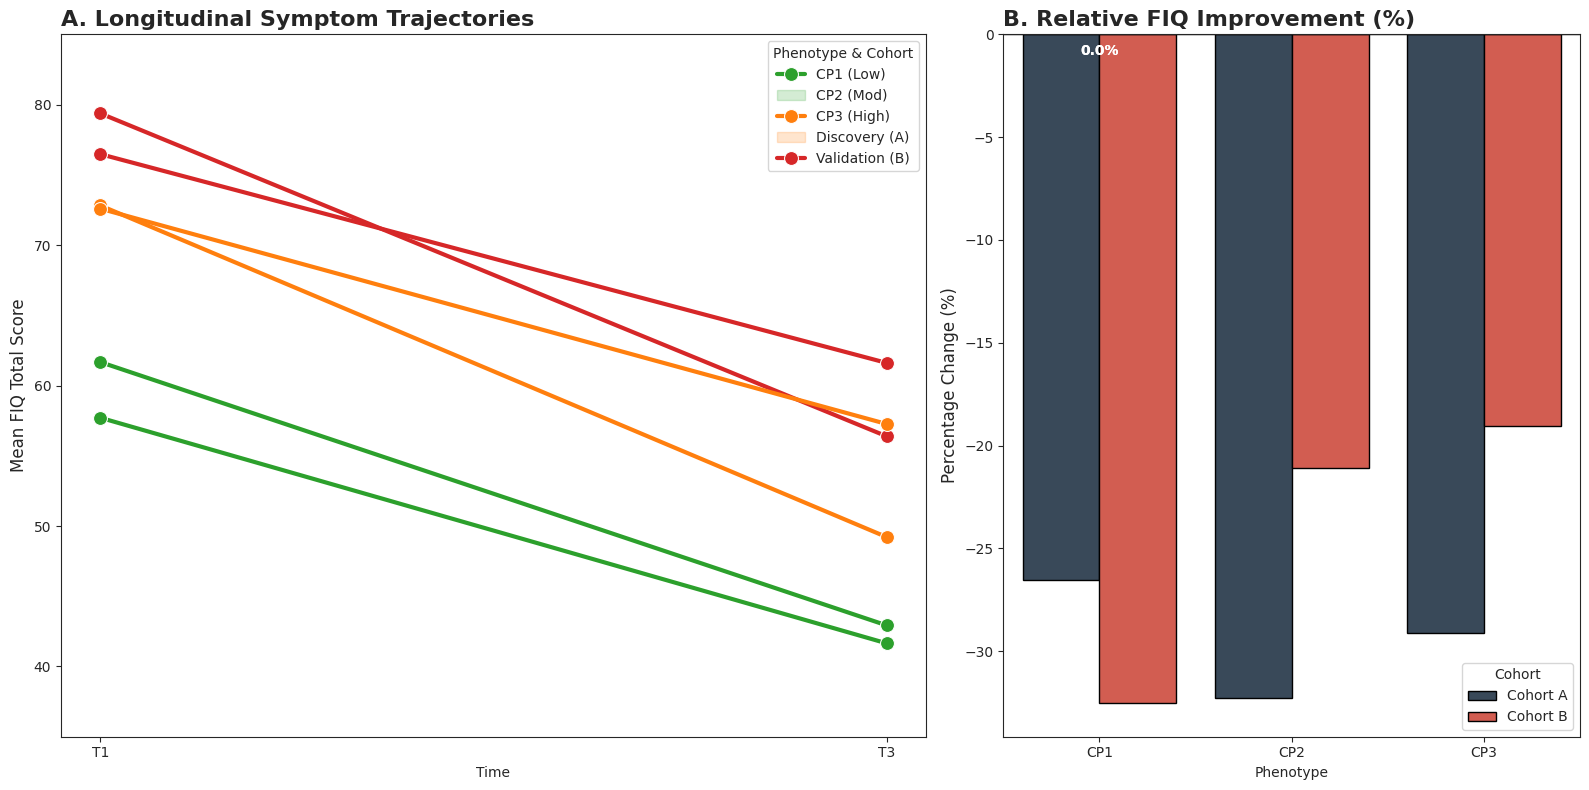

In [10]:
# =========================================================
# FIGURA COMPUESTA 5: TRAYECTORIAS Y CAMBIO RELATIVO (A vs B)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Mapeos y Configuración
mapeo_columnas = {
    df.columns[47]: 'FIQ_Total_Score',
    df.columns[14]: 'WPI_TOTAL',
    df.columns[51]: 'Fatigue_SSS',
    df.columns[52]: 'Sleep_SSS',
    df.columns[53]: 'Cognitive_SSS'
}
features_modelo = ['FIQ_Total_Score', 'WPI_TOTAL', 'Fatigue_SSS', 'Sleep_SSS', 'Cognitive_SSS']
c_id = df.columns[1]
c_sesion = df.columns[5]

def procesar_datos_completos(df_input, grupo_nombre):
    df_g = df_input[df_input['Cohort_Group'] == grupo_nombre].copy()
    t1_raw = df_g[df_g[c_sesion].astype(str).str.contains('Primera', na=False)].copy()
    t3_raw = df_g[df_g[c_sesion].astype(str).str.contains('Final|Tercera', na=False)].copy()

    def proyectar(df_temp):
        df_v = df_temp.rename(columns=mapeo_columnas)
        df_v = df_v.dropna(subset=features_modelo).copy()
        if df_v.empty: return pd.DataFrame()
        X_sc = scaler.transform(df_v[features_modelo])
        df_v['CP'] = kmeans.predict(X_sc)
        return df_v[[c_id, 'CP', 'FIQ_Total_Score']]

    res_t1 = proyectar(t1_raw)
    res_t3 = proyectar(t3_raw)
    df_ev = pd.merge(res_t1, res_t3, on=c_id, suffixes=('_T1', '_T3'))

    # Calcular cambio relativo
    df_ev['Rel_Change'] = ((df_ev['FIQ_Total_Score_T3'] - df_ev['FIQ_Total_Score_T1']) / df_ev['FIQ_Total_Score_T1']) * 100
    return df_ev

# 2. Generar DataFrames
data_ev_A = procesar_datos_completos(df, 'Group A')
data_ev_B = procesar_datos_completos(df, 'Group B')

# 3. Preparación para el Plot
# Datos trayectorias
def get_traj(df_ev, name):
    l = []
    for cp in [0,1,2]:
        sub = df_ev[df_ev['CP_T1']==cp]
        l.append({'CP': cp, 'Time': 'T1', 'FIQ': sub['FIQ_Total_Score_T1'].mean(), 'Cohort': name})
        l.append({'CP': cp, 'Time': 'T3', 'FIQ': sub['FIQ_Total_Score_T3'].mean(), 'Cohort': name})
    return pd.DataFrame(l)

df_traj = pd.concat([get_traj(data_ev_A, 'Cohort A'), get_traj(data_ev_B, 'Cohort B')])

# Datos barras
def get_bar(df_ev, name):
    res = df_ev.groupby('CP_T1')['Rel_Change'].mean().reset_index()
    res['Cohort'] = name
    return res

df_bar = pd.concat([get_bar(data_ev_A, 'Cohort A'), get_bar(data_ev_B, 'Cohort B')])
df_bar['Phenotype'] = df_bar['CP_T1'].map({0:'CP1', 1:'CP2', 2:'CP3'})

# 4. CREACIÓN DE LA FIGURA COMPUESTA
sns.set_style("ticks")
fig = plt.figure(figsize=(16, 8))
spec = fig.add_gridspec(1, 2, width_ratios=[1.2, 0.8])

# Panel A: Trayectorias
ax0 = fig.add_subplot(spec[0])
colores_traj = ['#2ca02c', '#ff7f0e', '#d62728']
for i, cohort in enumerate(['Cohort A', 'Cohort B']):
    ls = '-' if i==0 else '--'
    sns.lineplot(data=df_traj[df_traj['Cohort']==cohort], x='Time', y='FIQ', hue='CP',
                 palette=colores_traj, marker='o', markersize=10, linewidth=3, ax=ax0, style='Cohort', dashes=[(None,None),(2,2)])

ax0.set_title('A. Longitudinal Symptom Trajectories', fontsize=16, fontweight='bold', loc='left')
ax0.set_ylabel('Mean FIQ Total Score', fontsize=12)
ax0.set_ylim(35, 85)
ax0.legend(title='Phenotype & Cohort', labels=['CP1 (Low)', 'CP2 (Mod)', 'CP3 (High)', 'Discovery (A)', 'Validation (B)'])

# Panel B: Cambio Relativo
ax1 = fig.add_subplot(spec[1])
sns.barplot(data=df_bar, x='Phenotype', y='Rel_Change', hue='Cohort', palette=['#34495e', '#e74c3c'], ax=ax1, edgecolor='black')
ax1.set_title('B. Relative FIQ Improvement (%)', fontsize=16, fontweight='bold', loc='left')
ax1.set_ylabel('Percentage Change (%)', fontsize=12)
ax1.axhline(0, color='black', linewidth=1)

# Añadir etiquetas de valor en las barras
for p in ax1.patches:
    ax1.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width()/2., p.get_height()),
                 ha='center', va='center', xytext=(0, -12), textcoords='offset points', color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('Figure5_Composite_Final.png', dpi=300, bbox_inches='tight')
from google.colab import files
files.download('Figure5_Composite_Final.png')
plt.show()